In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import plotly.express as px

# NAV HISTORY
nav_df = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

# PERFORMANCE DATA
perf_df = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

# BENCHMARK
benchmark_df = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print("Datasets Loaded")

Datasets Loaded


compute daily returns

In [ ]:
#compute daily returns
nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
    .pct_change()
)

In [6]:
print(
    nav_df[
        ['date','amfi_code','nav','daily_return']
    ].head(10)
)
nav_df['daily_return'].describe()

         date  amfi_code       nav  daily_return
0  2022-01-03     100016  520.4608           NaN
1  2022-01-04     100016  515.0971     -0.010306
2  2022-01-05     100016  521.7239      0.012865
3  2022-01-06     100016  515.7880     -0.011377
4  2022-01-07     100016  515.1639     -0.001210
5  2022-01-10     100016  510.7136     -0.008639
6  2022-01-11     100016  513.5542      0.005562
7  2022-01-12     100016  512.3195     -0.002404
8  2022-01-13     100016  510.2445     -0.004050
9  2022-01-14     100016  514.3636      0.008073


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

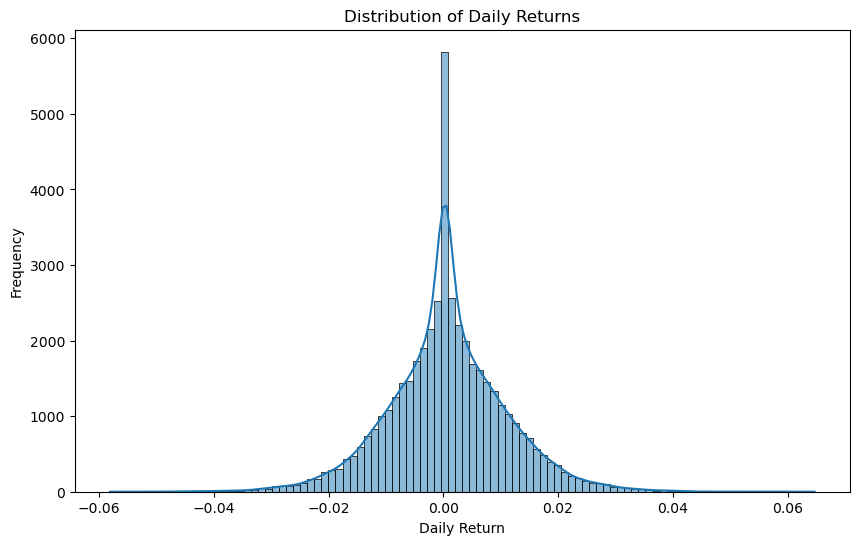

In [71]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title(
    'Distribution of Daily Returns'
)

plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.savefig(
    "../reports/performance_charts/Daily_Return_Distribution.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Insight 1: Daily Return Distribution

Daily returns are centered around zero with a roughly bell-shaped distribution, indicating normal market fluctuations. Extreme positive and negative return days are relatively rare.

compute CAGR FOR 1YR 3YR 5YR

In [ ]:
#CREATE CAGR FUNCTION
def calculate_cagr(start_nav, end_nav, years):

    return (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    ) * 100

In [9]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

In [10]:
#BUILD CAGR TABLE
cagr_results = []

latest_date = nav_df['date'].max()

for fund in nav_df['amfi_code'].unique():

    fund_df = nav_df[
        nav_df['amfi_code'] == fund
    ].sort_values('date')

    latest_nav = fund_df.iloc[-1]['nav']

    row = {
        'amfi_code': fund
    }

    for years in [1, 3, 5]:

        target_date = latest_date - pd.DateOffset(years=years)

        past_data = fund_df[
            fund_df['date'] <= target_date
        ]

        if len(past_data) > 0:

            start_nav = past_data.iloc[-1]['nav']

            row[f'{years}yr_cagr'] = calculate_cagr(
                start_nav,
                latest_nav,
                years
            )

        else:
            row[f'{years}yr_cagr'] = np.nan

    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)

In [11]:
#VIEW COMPARISION TABLE
print(cagr_df.head())

   amfi_code   1yr_cagr   3yr_cagr  5yr_cagr
0     100016  -2.224271   1.292649       NaN
1     100025   3.704969   3.916390       NaN
2     100033  53.232396  32.442459       NaN
3     101206  47.924120  28.967695       NaN
4     101207 -23.986032  -4.152381       NaN


In [12]:
#RANK FUNDS BY 3YR
top_cagr = (
    cagr_df
    .sort_values(
        '3yr_cagr',
        ascending=False
    )
)

top_cagr.head(10)

,amfi_code,1yr_cagr,3yr_cagr,5yr_cagr
16,119094,22.261065,35.111802,NaN
34,148567,20.360678,34.000916,NaN
24,120504,13.064279,32.487429,NaN
2,100033,53.232396,32.442459,NaN
25,120505,29.604659,31.777537,NaN
19,119551,60.437341,30.456524,NaN
30,120843,26.657082,29.582770,NaN
36,148569,39.751761,29.178902,NaN
3,101206,47.924120,28.967695,NaN
39,149324,65.138719,27.000427,NaN


In [13]:
#SAVING
cagr_df.to_csv(
    "../reports/Performance_charts/cagr_comparison.csv",
    index=False
)

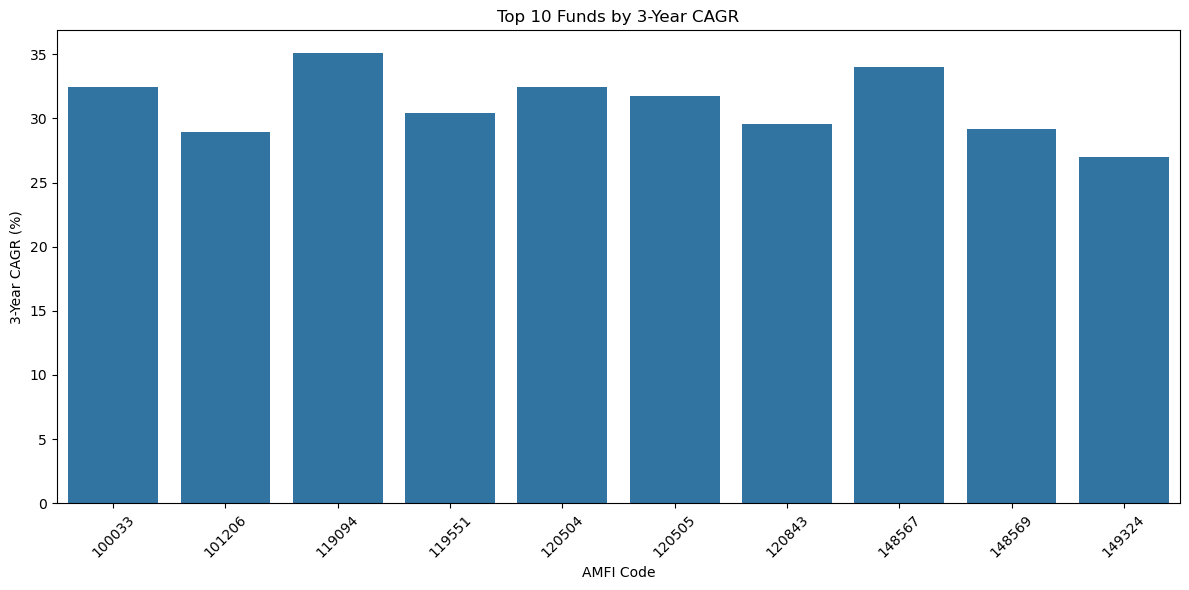

In [14]:
# TOP 10 FUNDS BY 3-YEAR CAGR

top10_cagr = (
    cagr_df
    .sort_values(
        '3yr_cagr',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_cagr,
    x='amfi_code',
    y='3yr_cagr'
)

plt.title(
    'Top 10 Funds by 3-Year CAGR'
)

plt.xlabel('AMFI Code')
plt.ylabel('3-Year CAGR (%)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../Charts/cagr_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Insight 2: CAGR Comparison

The top-performing funds delivered the highest 3-year CAGR, indicating strong long-term wealth creation potential. Funds with consistently higher CAGR values outperformed peers across multiple market cycles.

SHARPE RATIO

In [15]:
#RISK FREE RATE
rf = 0.065   # 6.5%
daily_rf = rf / 252

In [17]:
#CRAETE RETURNS
# SORT DATA

nav_df = nav_df.sort_values(
    ['amfi_code', 'date']
)
returns = nav_df.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)
returns = returns.pct_change()
print(returns.head())

amfi_code     100016    100025    100033    101206    101207    101208  \
date                                                                     
2022-01-03       NaN       NaN       NaN       NaN       NaN       NaN   
2022-01-04 -0.010306 -0.003553 -0.013328  0.001153 -0.010865 -0.000141   
2022-01-05  0.012865 -0.000050 -0.004386  0.003866  0.000603  0.000382   
2022-01-06 -0.011377 -0.001880 -0.005167 -0.002128 -0.029101 -0.000143   
2022-01-07 -0.001210  0.002036 -0.005748 -0.006314  0.024766  0.000215   

amfi_code     102885    102886    102887    118632  ...    120843    120844  \
date                                                ...                       
2022-01-03       NaN       NaN       NaN       NaN  ...       NaN       NaN   
2022-01-04  0.011122  0.011314 -0.010459 -0.000714  ...  0.018160  0.000243   
2022-01-05 -0.007878  0.006779 -0.005308  0.005913  ... -0.012304  0.000462   
2022-01-06  0.015277  0.031127  0.012678  0.003540  ...  0.008509  0.000650   
2022-01

In [18]:
#CALCULATE SHARPE RATIO FOR EACH FUND
sharpe_results = []
for fund in returns.columns:
    fund_returns = returns[fund].dropna()
    mean_return = fund_returns.mean()
    std_return = fund_returns.std()
    sharpe = (
        (mean_return - daily_rf)
        / std_return
    ) * np.sqrt(252)
    sharpe_results.append({
        'amfi_code': fund,
        'sharpe_ratio': sharpe
    })
sharpe_df = pd.DataFrame(sharpe_results)

In [19]:
#RANK ALL FUNDA
sharpe_df = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
)
sharpe_df['rank'] = range(
    1,
    len(sharpe_df) + 1
)
print(sharpe_df.head(10))

    amfi_code  sharpe_ratio  rank
34     148567      1.448291     1
30     120843      1.306744     2
36     148569      1.234930     3
19     119551      1.208267     4
25     120505      1.180101     5
38     149323      1.132122     6
2      100033      1.093699     7
9      118632      1.081659     8
3      101206      1.027213     9
24     120504      1.026524    10


In [20]:
#SAVINGV 
sharpe_df.to_csv(
    "../reports/Performance_charts/sharpe_ratio.csv",
    index=False
)

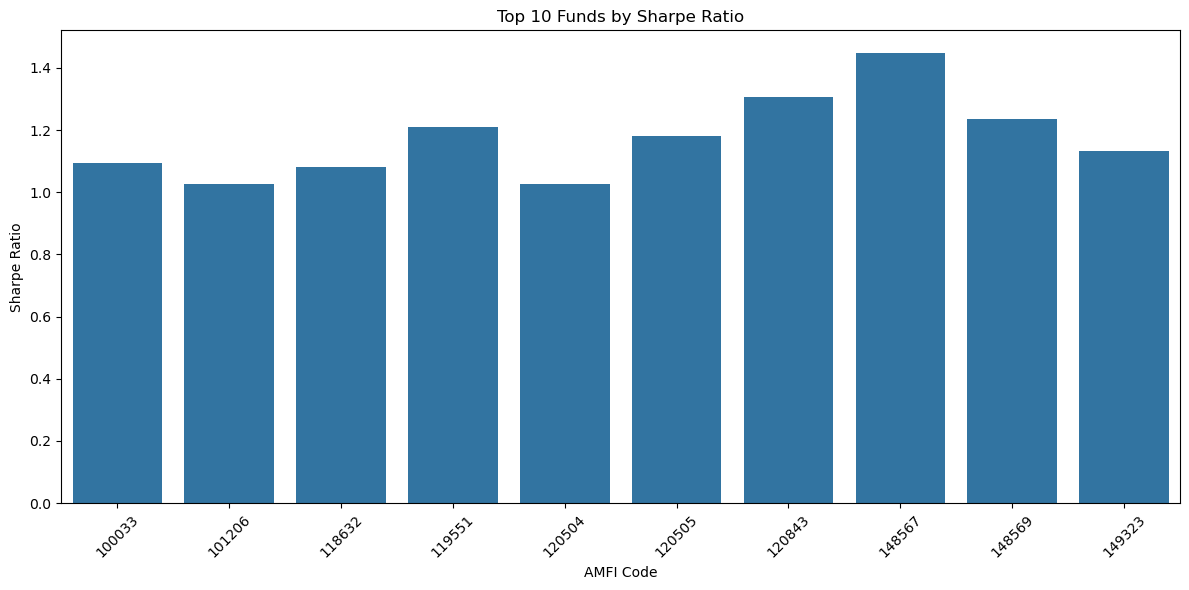

In [21]:
#VISUALIZE TOP 10 FUNDS
top10_sharpe = sharpe_df.head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_sharpe,
    x='amfi_code',
    y='sharpe_ratio'
)
plt.title(
    'Top 10 Funds by Sharpe Ratio'
)
plt.xlabel('AMFI Code')
plt.ylabel('Sharpe Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "../Charts/sharpe_ratio.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Insight 3: Sharpe Ratio Ranking

Funds with the highest Sharpe Ratios delivered superior risk-adjusted returns, generating higher returns per unit of risk taken. These funds demonstrated more efficient performance compared to peers during the analysis period.

Supporting Chart: Top 10 Funds by Sharpe Ratio

SORTINO RATIO

In [ ]:
#CALCULATE SORTINO RATIO

In [22]:
# CALCULATE SORTINO RATIO
sortino_results = []
for fund in returns.columns:
    fund_returns = returns[fund].dropna()
    mean_return = fund_returns.mean()
    # ONLY NEGATIVE RETURNS
    downside_returns = fund_returns[
        fund_returns < 0
    ]
    downside_std = downside_returns.std()
    sortino = (
        (mean_return - daily_rf)
        / downside_std
    ) * np.sqrt(252)
    sortino_results.append({
        'amfi_code': fund,
        'sortino_ratio': sortino
    })
sortino_df = pd.DataFrame(sortino_results)
print(sortino_df.head())

   amfi_code  sortino_ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644


In [23]:
#RANK ALL FUNDS
sortino_df = sortino_df.sort_values(
    'sortino_ratio',
    ascending=False
)
sortino_df['rank'] = range(
    1,
    len(sortino_df) + 1
)
sortino_df.head(10)

,amfi_code,sortino_ratio,rank
34,148567,2.385644,1
30,120843,2.364320,2
36,148569,2.146914,3
19,119551,2.140267,4
25,120505,2.029353,5
38,149323,1.875101,6
9,118632,1.850133,7
2,100033,1.829134,8
24,120504,1.805294,9
3,101206,1.799563,10


In [24]:
#SAVING
sortino_df.to_csv(
    "../reports/Performance_charts/sortino_ratio.csv",
    index=False
)

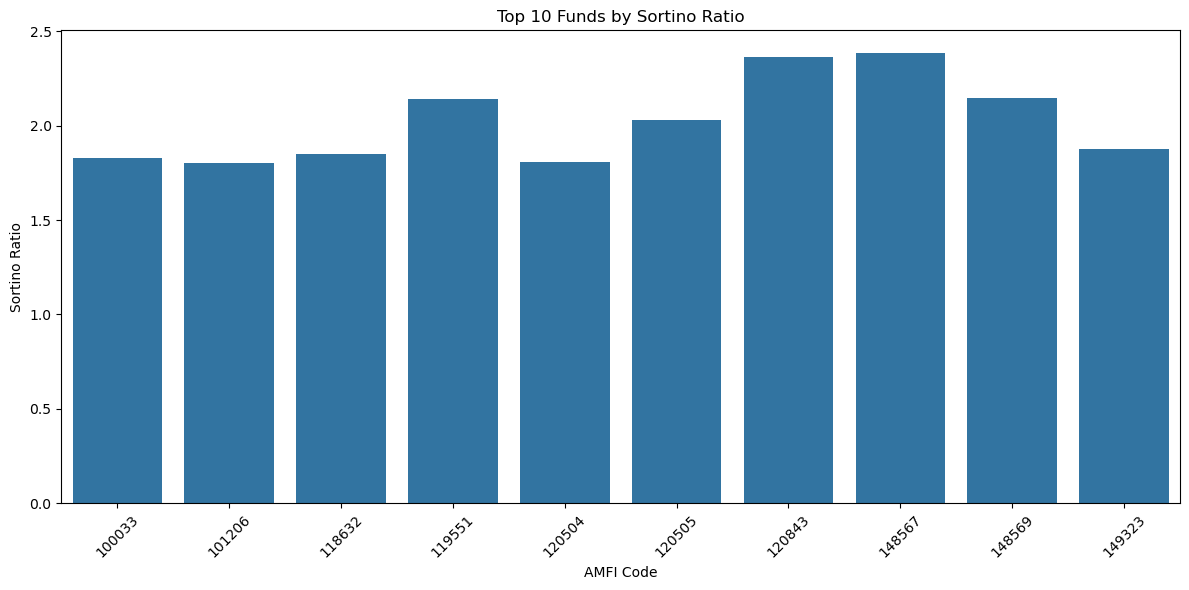

In [25]:
#TOP 10 CHARTS
plt.figure(figsize=(12,6))
sns.barplot(
    data=sortino_df.head(10),
    x='amfi_code',
    y='sortino_ratio'
)
plt.title(
    'Top 10 Funds by Sortino Ratio'
)
plt.xlabel('AMFI Code')
plt.ylabel('Sortino Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "../Charts/sortino_ratio.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Insight 4: Sortino Ratio Analysis

Funds with the highest Sortino Ratios delivered superior risk-adjusted returns while minimizing downside volatility. These schemes were more effective at protecting investors during negative market movements.

Supporting Chart: Top 10 Funds by Sortino Ratio

ALPHA ANAD BETA

In [27]:
#PREPARE BENCHMARK RETURNS
# CONVERT DATE

benchmark_df['date'] = pd.to_datetime(
    benchmark_df['date']
)
# FILTER NIFTY100

nifty100 = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY100'
].copy()
# DAILY RETURNS
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)
print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [28]:
#CREATE ALPHA BETA TABLE
from scipy.stats import linregress
alpha_beta_results = []

In [29]:
#RUN REGRESSIO FOR EVERY FUND
for fund in returns.columns:
    fund_returns = (
        returns[fund]
        .dropna()
        .reset_index()
    )
    fund_returns.columns = [
        'date',
        'fund_return'
    ]
    merged = pd.merge(
        fund_returns,
        nifty100[
            ['date',
             'benchmark_return']
        ],
        on='date',
        how='inner'
    )
    merged = merged.dropna()
    if len(merged) > 30:
        slope, intercept, r_value, p_value, std_err = linregress(
            merged['benchmark_return'],
            merged['fund_return']
        )
        alpha_beta_results.append({
            'amfi_code': fund,
            'alpha': intercept * 252,
            'beta': slope,
            'r_squared': r_value ** 2
        })

In [30]:
#CREATE DATAFRAME
alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)
alpha_beta_df.head()

,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [31]:
#SAVING
alpha_beta_df.to_csv(
    "../reports/Performance_charts/alpha_beta.csv",
    index=False
)

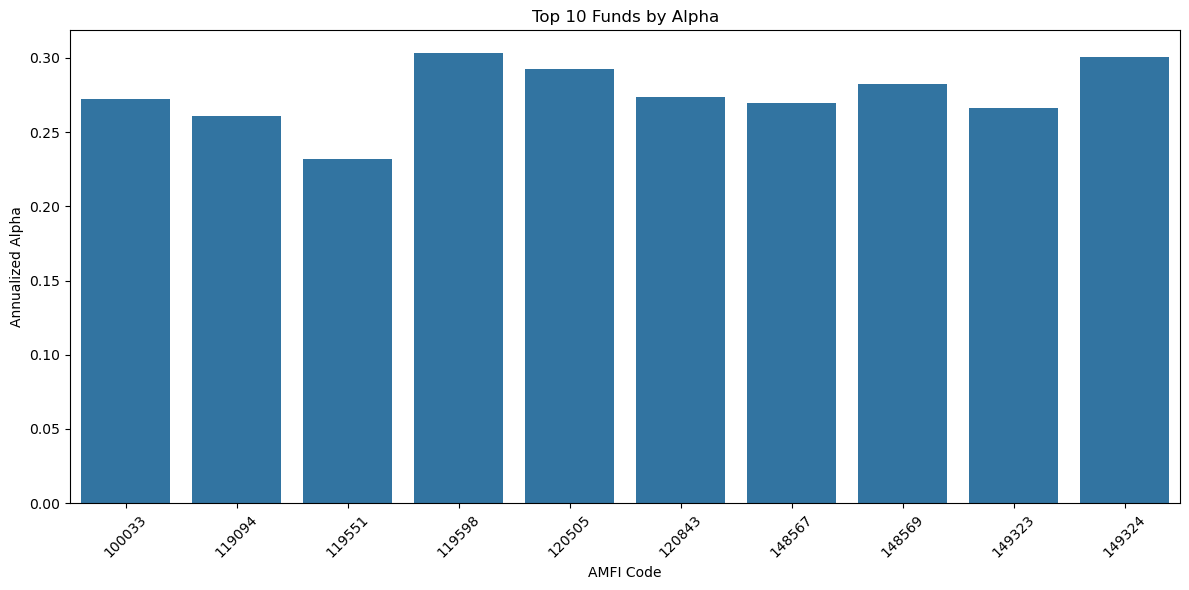

In [ ]:
#TOP ALPHA CHARTS
top_alpha = (
    alpha_beta_df
    .sort_values(
        'alpha',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x='amfi_code',
    y='alpha'
)

plt.title(
    'Top 10 Funds by Alpha'
)

plt.xlabel('AMFI Code')
plt.ylabel('Annualized Alpha')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../Charts/alpha_ranking.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

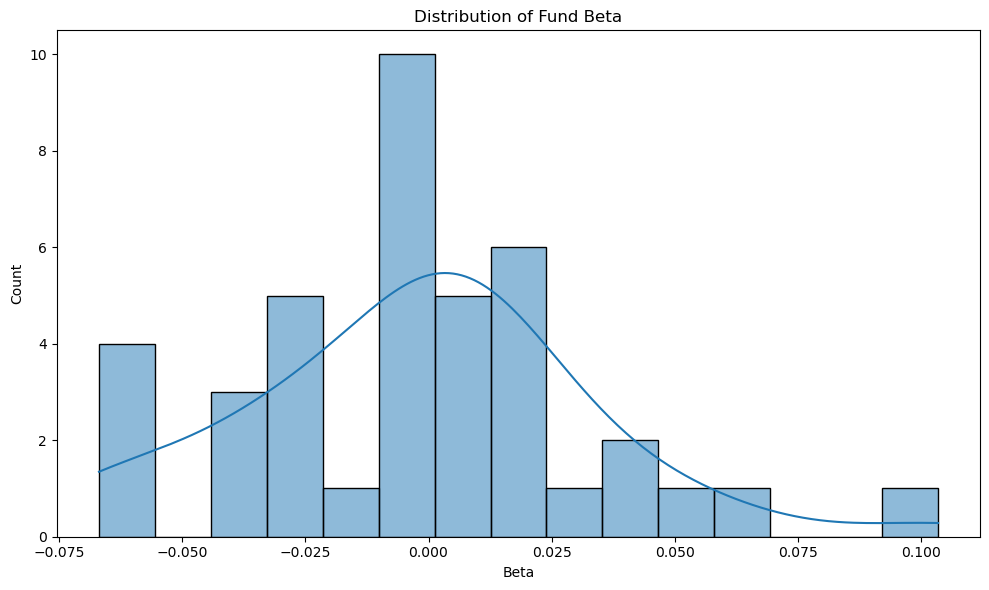

In [34]:
#BETA DISTRIBUTION CHART
plt.figure(figsize=(10,6))
sns.histplot(
    alpha_beta_df['beta'],
    bins=15,
    kde=True
)

plt.title(
    'Distribution of Fund Beta'
)
plt.xlabel('Beta')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(
    "../Charts/beta_distribution.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Insight 5: Alpha and Beta Analysis

Several funds generated positive annualized alpha, indicating outperformance relative to the Nifty 100 benchmark after adjusting for market risk. Most funds exhibited beta values close to 1, suggesting return movements largely tracked overall market behavior.

Supporting Charts:
1. Top 10 Funds by Alpha
2. Beta Distribution of Mutual Funds

MAXIMUM DRAWDOWN(MDD)

In [35]:
# CALCULATE MAXIMUM DRAWDOWN
mdd_results = []
for fund in nav_df['amfi_code'].unique():
    fund_df = (
        nav_df[
            nav_df['amfi_code'] == fund
        ]
        .sort_values('date')
        .copy()
    )
    # Running maximum NAV
    fund_df['running_max'] = (
        fund_df['nav']
        .cummax()
    )
    # Drawdown
    fund_df['drawdown'] = (
        fund_df['nav']
        /
        fund_df['running_max']
        - 1
    )
    # Worst drawdown
    worst_idx = fund_df['drawdown'].idxmin()
    worst_row = fund_df.loc[worst_idx]
    mdd_results.append({
        'amfi_code': fund,
        'max_drawdown_pct':
            worst_row['drawdown'] * 100,
        'worst_date':
            worst_row['date']
    })

mdd_df = pd.DataFrame(mdd_results)
print(mdd_df.head())

   amfi_code  max_drawdown_pct worst_date
0     100016        -24.734441 2022-09-15
1     100025         -4.308264 2023-07-28
2     100033        -16.217209 2022-05-12
3     101206        -11.291596 2023-07-05
4     101207        -35.446916 2026-05-11


In [36]:
#RANK FUNDS
mdd_df = mdd_df.sort_values(
    'max_drawdown_pct'
)
mdd_df.head(10)

,amfi_code,max_drawdown_pct,worst_date
22,119599,-52.574221,2025-10-28
17,119095,-51.677754,2026-05-11
4,101207,-35.446916,2026-05-11
39,149324,-31.171900,2025-01-03
21,119598,-28.706006,2025-05-14
7,102886,-28.001124,2026-04-27
0,100016,-24.734441,2022-09-15
29,120842,-24.003511,2024-10-17
11,118634,-23.344886,2026-02-20
15,119093,-21.751396,2023-05-22


In [37]:
#SAVING
mdd_df.to_csv(
    "../reports/Performance_charts/max_drawdown.csv",
    index=False
)

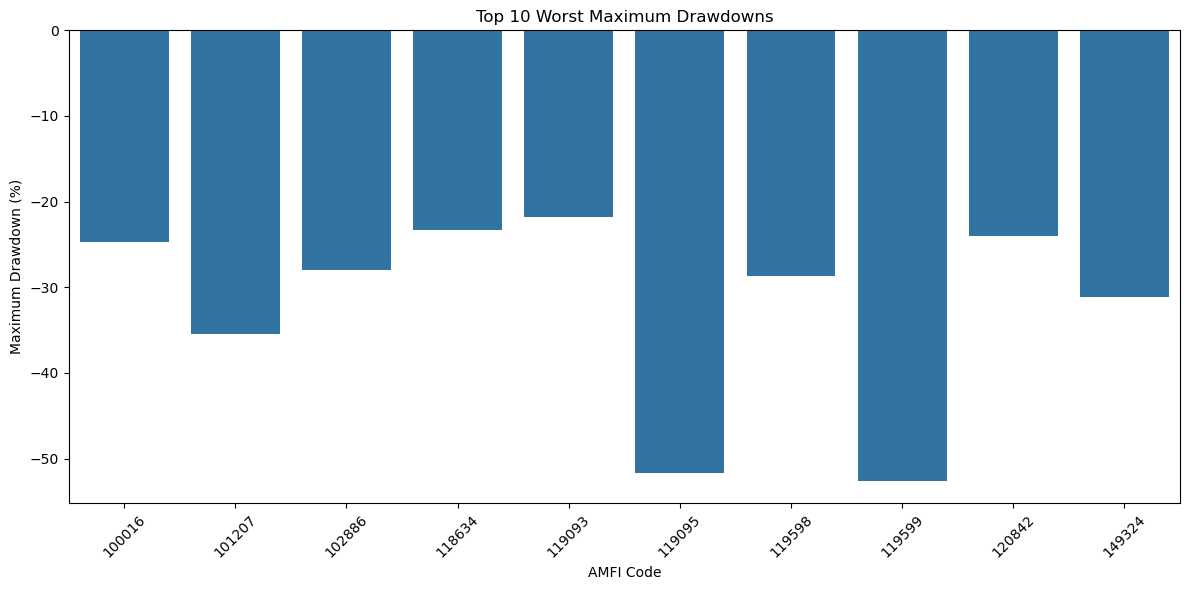

In [38]:
#TOP 10 WORST DRAWDOWNS CHART
plt.figure(figsize=(12,6))
worst10 = (
    mdd_df
    .sort_values('max_drawdown_pct')
    .head(10)
)
sns.barplot(
    data=worst10,
    x='amfi_code',
    y='max_drawdown_pct'
)
plt.title(
    'Top 10 Worst Maximum Drawdowns'
)
plt.xlabel('AMFI Code')
plt.ylabel('Maximum Drawdown (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "../Charts/max_drawdown.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [39]:
#FIND WORST DRAWDOWN DATE RANGE
worst_fund = mdd_df.loc[
    mdd_df['max_drawdown_pct'].idxmin()
]

print(worst_fund)

amfi_code                        119599
max_drawdown_pct             -52.574221
worst_date          2025-10-28 00:00:00
Name: 22, dtype: object


In [ ]:
fund_code = worst_fund['amfi_code']
fund_df = (
    nav_df[
        nav_df['amfi_code'] == fund_code
    ]
    .sort_values('date')
    .copy()
)
fund_df['running_max'] = (
    fund_df['nav']
    .cummax()
)
fund_df['drawdown'] = (
    fund_df['nav']
    /
    fund_df['running_max']
    - 1
)
worst_row = fund_df.loc[
    fund_df['drawdown'].idxmin()
]
print(
    "Worst Drawdown Date:",
    worst_row['date']
)

Worst Drawdown Date: 2025-10-28 00:00:00


## Insight 6: Maximum Drawdown Analysis

The worst-performing funds experienced drawdowns exceeding 20–30% from their peak NAV levels, highlighting periods of significant downside risk. Funds with lower maximum drawdowns demonstrated stronger capital preservation during market corrections.

Supporting Chart: Top 10 Worst Maximum Drawdowns

FUND SCORECARD(0-100)

In [42]:
print(perf_df.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'return_1yr_pct_anomaly', 'return_3yr_pct_anomaly', 'return_5yr_pct_anomaly', 'expense_ratio_valid']


In [43]:
#MERGE ALL METRICS
scorecard = (
    cagr_df[['amfi_code', '3yr_cagr']]
    .merge(
        sharpe_df[['amfi_code', 'sharpe_ratio']],
        on='amfi_code'
    )
    .merge(
        alpha_beta_df[['amfi_code', 'alpha']],
        on='amfi_code'
    )
    .merge(
        perf_df[['amfi_code', 'expense_ratio_pct']],
        on='amfi_code'
    )
    .merge(
        mdd_df[['amfi_code', 'max_drawdown_pct']],
        on='amfi_code'
    )
)

scorecard.head()

,amfi_code,3yr_cagr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct
0,100016,1.292649,-0.201517,0.037476,1.55,-24.734441
1,100025,3.916390,-0.567095,0.042818,0.56,-4.308264
2,100033,32.442459,1.093699,0.271954,1.38,-16.217209
3,101206,28.967695,1.027213,0.213998,1.60,-11.291596
4,101207,-4.152381,0.162661,0.108971,1.53,-35.446916


In [44]:
#Step 2: Create Ranks
#Higher is better:
# CAGR
# Sharpe
# Alpha
# Lower is better:
# Expense Ratio
# Maximum Drawdown
scorecard['cagr_rank'] = (
    scorecard['3yr_cagr']
    .rank(ascending=False)
)
scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)
scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(ascending=False)
)
scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(ascending=True)
)
scorecard['mdd_rank'] = (
    scorecard['max_drawdown_pct']
    .rank(ascending=False)
)

In [45]:
#Step 3: Convert Ranks to Percent Scores
n = len(scorecard)
scorecard['cagr_score'] = (
    (n - scorecard['cagr_rank']) / (n - 1)
) * 100
scorecard['sharpe_score'] = (
    (n - scorecard['sharpe_rank']) / (n - 1)
) * 100
scorecard['alpha_score'] = (
    (n - scorecard['alpha_rank']) / (n - 1)
) * 100
scorecard['expense_score'] = (
    (n - scorecard['expense_rank']) / (n - 1)
) * 100
scorecard['mdd_score'] = (
    (n - scorecard['mdd_rank']) / (n - 1)
) * 100

In [46]:
#Step 4: Calculate Final Fund Score
#Weights:
#30% CAGR
##25% Sharpe
#20% Alpha
#15% Expense Ratio
#10% Maximum Drawdown
scorecard['fund_score'] = (
      scorecard['cagr_score'] * 0.30
    + scorecard['sharpe_score'] * 0.25
    + scorecard['alpha_score'] * 0.20
    + scorecard['expense_score'] * 0.15
    + scorecard['mdd_score'] * 0.10
)

In [47]:
#RANK FUNDS
scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)
scorecard.head(10)

,amfi_code,3yr_cagr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,cagr_score,sharpe_score,alpha_score,expense_score,mdd_score,fund_score
34,148567,34.000916,1.448291,0.269838,1.46,-11.265729,2.0,1.0,7.0,23.0,8.0,97.435897,100.000000,84.615385,43.589744,82.051282,85.897436
25,120505,31.777537,1.180101,0.292636,1.36,-18.188514,5.0,5.0,3.0,15.0,25.0,89.743590,89.743590,94.871795,64.102564,38.461538,81.794872
30,120843,29.582770,1.306744,0.273305,1.45,-12.973968,7.0,2.0,5.0,22.0,13.0,84.615385,97.435897,89.743590,46.153846,69.230769,81.538462
2,100033,32.442459,1.093699,0.271954,1.38,-16.217209,4.0,7.0,6.0,17.0,20.0,92.307692,84.615385,87.179487,58.974359,51.282051,80.256410
24,120504,32.487429,1.026524,0.211948,0.80,-12.588276,3.0,10.0,13.0,12.0,12.0,94.871795,76.923077,69.230769,71.794872,71.794872,79.487179
16,119094,35.111802,0.998231,0.260767,1.38,-20.960884,1.0,11.0,9.0,17.0,28.0,100.000000,74.358974,79.487179,58.974359,30.769231,76.410256
19,119551,30.456524,1.208267,0.232010,1.54,-15.012385,6.0,4.0,10.0,30.5,17.0,87.179487,92.307692,76.923077,24.358974,58.974359,74.166667
36,148569,29.178902,1.234930,0.282704,1.60,-16.396743,8.0,3.0,4.0,36.5,21.0,82.051282,94.871795,92.307692,8.974359,48.717949,73.012821
3,101206,28.967695,1.027213,0.213998,1.60,-11.291596,9.0,9.0,12.0,36.5,9.0,79.487179,79.487179,71.794872,8.974359,79.487179,67.371795
21,119598,26.669922,0.945308,0.303370,1.43,-28.706006,12.0,14.0,1.0,21.0,36.0,71.794872,66.666667,100.000000,48.717949,10.256410,66.538462


In [48]:
#SAVING
scorecard.to_csv(
    "../reports/Performance_charts/fund_scorecard.csv",
    index=False
)

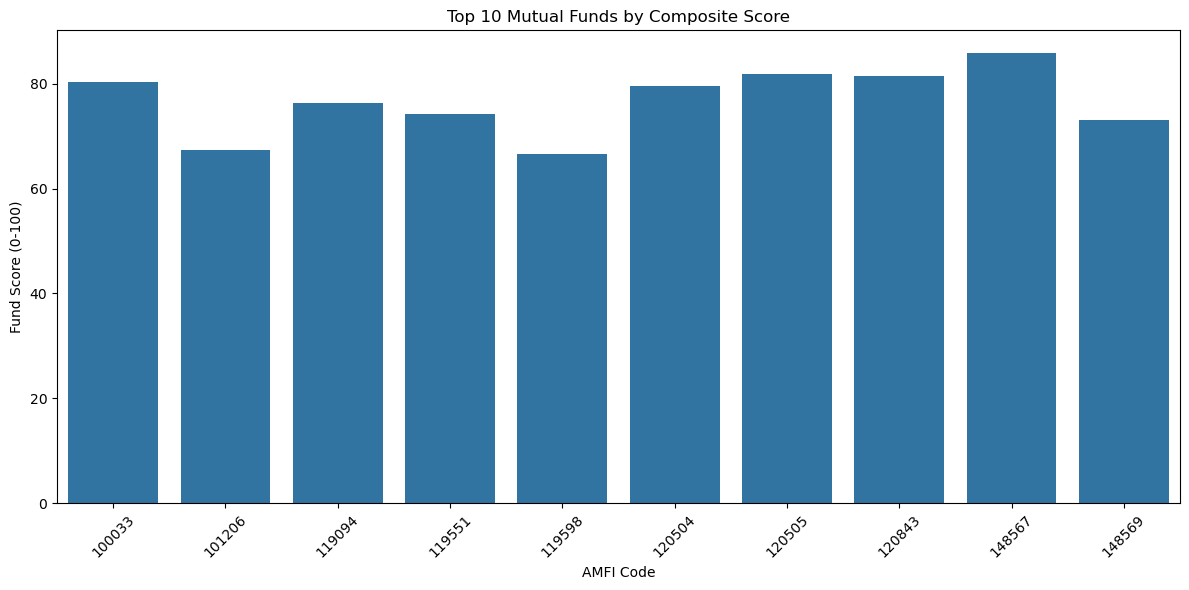

In [49]:
#TOP 10 FUUND SCORE CHART
plt.figure(figsize=(12,6))
top10 = scorecard.head(10)
sns.barplot(
    data=top10,
    x='amfi_code',
    y='fund_score'
)
plt.title(
    'Top 10 Mutual Funds by Composite Score'
)
plt.xlabel('AMFI Code')
plt.ylabel('Fund Score (0-100)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "../Charts/fund_scorecard.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Insight 7: Fund Scorecard Ranking

Funds that combined strong 3-year CAGR, superior risk-adjusted returns (Sharpe Ratio), positive alpha generation, lower expense ratios, and controlled drawdowns achieved the highest composite scores. These funds demonstrated balanced performance across both return and risk dimensions.

Supporting Chart: Top 10 Mutual Funds by Composite Score

BENCHMARK COMPARISION CHART

In [50]:
#SELECT TP 5 FUNDS FROM SCORECARD
top5_funds = (
    scorecard
    .sort_values(
        'fund_score',
        ascending=False
    )
    .head(5)['amfi_code']
    .tolist()
)
print(top5_funds)

[148567, 120505, 120843, 100033, 120504]


In [51]:
#PREPARE BENCHMARK DATA
benchmark_df['date'] = pd.to_datetime(
    benchmark_df['date'],
    dayfirst=True
)
nav_df['date'] = pd.to_datetime(
    nav_df['date']
)

In [52]:
#KEEP ONLY NIFTY 50 AND NIFTY100
bench = benchmark_df[
    benchmark_df['index_name'].isin(
        ['NIFTY50', 'NIFTY100']
    )
]

In [53]:
#KEEP LAST 3 YEAR
end_date = nav_df['date'].max()
start_date = end_date - pd.DateOffset(years=3)

In [54]:
#NORMALIZE NAV
comparison_df = pd.DataFrame()

In [55]:
#TOP 5 FUNDS
for fund in top5_funds:

    temp = nav_df[
        (nav_df['amfi_code'] == fund) &
        (nav_df['date'] >= start_date)
    ].copy()

    temp = temp.sort_values('date')

    temp['normalized'] = (
        temp['nav']
        /
        temp['nav'].iloc[0]
    ) * 100

    temp['series'] = str(fund)

    comparison_df = pd.concat(
        [comparison_df, temp]
    )

In [56]:
#NIFTTY 50
nifty50 = bench[
    (bench['index_name'] == 'NIFTY50') &
    (bench['date'] >= start_date)
].copy()

nifty50['normalized'] = (
    nifty50['close_value']
    /
    nifty50['close_value'].iloc[0]
) * 100

nifty50['series'] = 'NIFTY50'

comparison_df = pd.concat(
    [comparison_df, nifty50]
)

In [57]:
#NIFTY 100
nifty100 = bench[
    (bench['index_name'] == 'NIFTY100') &
    (bench['date'] >= start_date)
].copy()

nifty100['normalized'] = (
    nifty100['close_value']
    /
    nifty100['close_value'].iloc[0]
) * 100

nifty100['series'] = 'NIFTY100'

comparison_df = pd.concat(
    [comparison_df, nifty100]
)

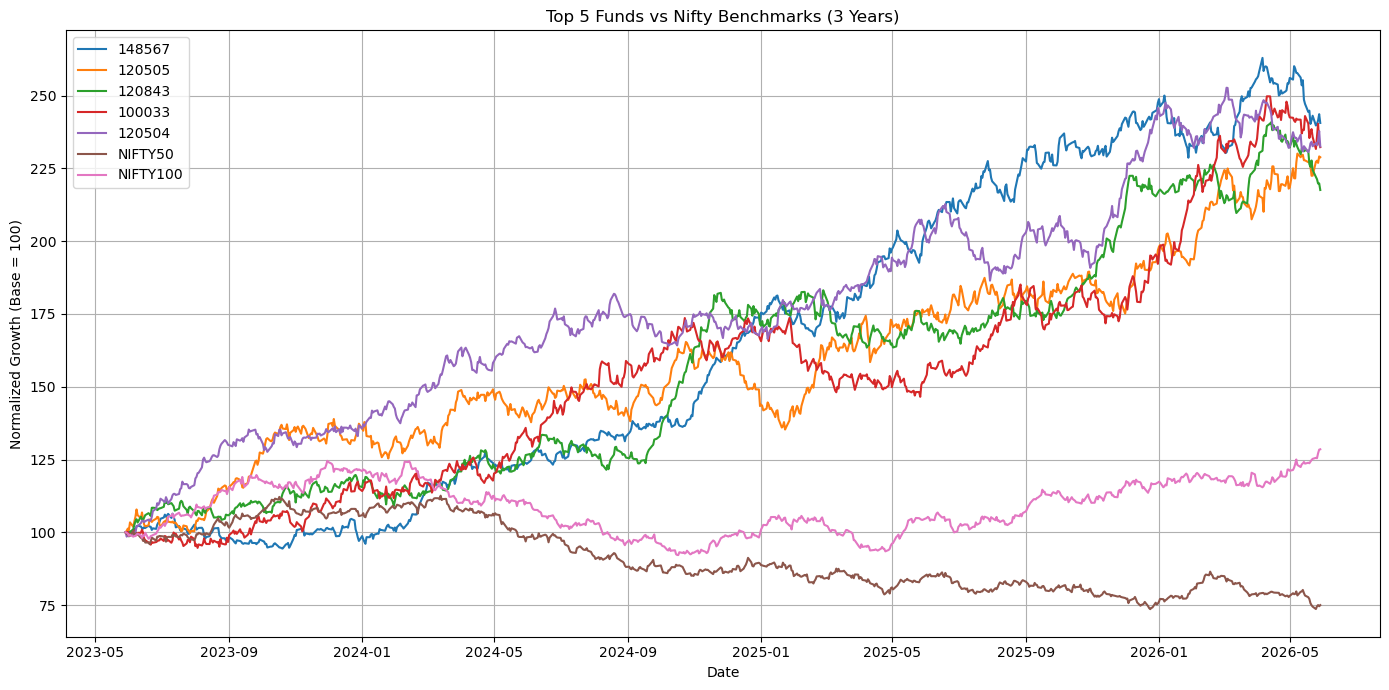

<Figure size 640x480 with 0 Axes>

In [ ]:
#BENCHMARK COMPARISON CHART
plt.figure(figsize=(14,7))
for series in comparison_df['series'].unique():
    temp = comparison_df[
        comparison_df['series'] == series
    ]
    plt.plot(
        temp['date'],
        temp['normalized'],
        label=series
    )
plt.title(
    'Top 5 Funds vs Nifty Benchmarks (3 Years)'
)
plt.xlabel('Date')
plt.ylabel('Normalized Growth (Base = 100)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "../Charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


In [ ]:
#BENCHMARK RETURNS
nifty100_returns = (
    nifty100
    .sort_values('date')
)
nifty100_returns['benchmark_return'] = (
    nifty100_returns['close_value']
    .pct_change()
)

In [63]:
#TRACKING ERROR CALCULATING
tracking_results = []

for fund in top5_funds:

    fund_df = nav_df[
        nav_df['amfi_code'] == fund
    ].copy()

    fund_df = fund_df.sort_values('date')

    fund_df['fund_return'] = (
        fund_df['nav']
        .pct_change()
    )

    merged = pd.merge(
        fund_df[['date','fund_return']],
        nifty100_returns[
            ['date','benchmark_return']
        ],
        on='date'
    )

    tracking_error = (
        (
            merged['fund_return']
            -
            merged['benchmark_return']
        ).std()
    ) * np.sqrt(252)

    tracking_results.append({
        'amfi_code': fund,
        'tracking_error': tracking_error
    })

In [64]:
#TRACKING ERROR TABLE
tracking_df = pd.DataFrame(
    tracking_results
)

tracking_df.sort_values(
    'tracking_error'
)

,amfi_code,tracking_error
4,120504,0.187299
0,148567,0.187974
2,120843,0.206540
3,100033,0.224976
1,120505,0.232661


In [66]:
#SAVING
tracking_df.to_csv(
    "../reports/Performance_charts/benchmark_tracking error.csv",
    index=False
)

## Insight 8: Benchmark Comparison

The top-ranked funds consistently outperformed the Nifty benchmarks over the last three years. Lower tracking error values indicate closer benchmark replication, while higher tracking errors suggest more active portfolio management and differentiated returns.

Supporting Chart: Top 5 Funds vs Nifty 50 and Nifty 100 (3 Years)